# Create 2D digital aerial imagery products

## Introduction

This tutorial demonstrates how to automate photogrammetric correction of digital aerial imagery and generate reality mapping products using the ArcGIS API for Python. You'll learn to create Digital Surface Models (DSM), Digital Terrain Models (DTM), true ortho imagery, and DSM Mesh products. In this workflow, you will process a collection of nadir digital aerial images through the complete reality mapping pipeline, including:

- Creating a project and mission
- Performing block adjustment
- Generating products

The [dataset for this tutorial](https://esri-rasterdev.maps.arcgis.com/home/item.html?id=086cb85d47b9484989f4ea8545c2034f&rsource=https%3A%2F%2Flinks.esri.com%2FRealityMapping2D_AerialTutorialData) was provided by Vexcel Imaging, and is comprised of 64 nadir digital aerial images covering a section of Hollywood, California. The required frames and cameras table needed to support the block adjustment process is also provided. The path in each of the entries of the Raster column of the frame table need to be updated to the correct path you save the data on your computer. We recommend using a UNC path or datastore path.

## Getting Started

Reality mapping capability through ArcGIS API for Python requires ArcGIS Enterprise federated with a Reality Server license. See the [configuration instruction](https://doc.esri.com/en/arcgis-reality-server/latest/deploy/configure-arcgis-reality.html) for setup details.

Once your environment is configured, import the required class and module:

- [GIS](/python/latest/api-reference/arcgis.gis.toc.html#gis) class: Represents the organizational deployment and accesses classes to manage content, users, and groups

-  [arcgis.raster.realitymapping](/python/latest/api-reference/arcgis.raster.realitymapping.html) submodule provides the functionality to automate reality mapping tasks in the server environment. The reality mapping module is available with ArcGIS API for Python (version >= 2.4.2)

In [2]:
from arcgis.gis import GIS
from arcgis.raster import realitymapping

Establish a connection to your ArcGIS Enterprise portal and verify that reality mapping is supported in your environment. 

> *note:* Change credentials to match your organization credentials.

In [ ]:
#connect to GIS
gis = GIS(
    url= "https://yourportal.domain.com/portal",
    username= "your username",
    password= "your password"
)

# confirm that reality mapping is supported
realitymapping.is_supported(gis)

## Step 1: Create a Project

The first step is to create a reality mapping project using the [Project](python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster.realitymapping.Project) class of the reality mapping module. For this example, we are using nadir digital aerial data, so we set the `sensor_type` and `scenario_type` accordingly.

In [ ]:
project = realitymapping.Project(
            project= "RMDigitalAerial2Dy", 
            sensor_type = "AerialDigital", 
            scenario_type= "AerialNadir"
)
project

A project is a top-level workspace for managing reality mapping activities. Project creation involves creating a new portal folder and a reality mapping project item inside that folder. The project item contains the basic information (e.g. project name, group name, workspace name, etc.) that defines a reality mapping project. All related image services and products generated in subsequent steps will be stored in the project folder.

In [4]:
# Project item id
project.item.itemid

'e1f817a309cd41f3ac1075628ddd65ae'

## Step 2: Create a Mission

The next step is to create a mission which is a container for managing all related imagery and the resulting processed data products of a single data capture session. Mission creation involves creating an image collection for the source rasters. So we need to first define the type, properties and path of the source rasters using the [ImageSource](/python/latest/api-reference/arcgis.raster.toc.html#imagesource) class.

In [ ]:
# Create an image source of Frame Camera type
DA_src = realitymapping.ImageSource("Frame Camera")
# Define the camera table and dem
DA_src.raster_type.camera_info = r"C:\SampleData\RM_DigitalAerial_Tutorial_2D\Nadir_Frames.csv"
DA_src.raster_type.dem = r"C:\SampleData\RM_DigitalAerial_Tutorial_2D\DEM\DEM_USGS_1m.tif"
# Define the source rasters' path
DA_src.input_data = r"C:\SampleData\RM_DigitalAerial_Tutorial_2D\Nadir_FramesCam.csv"

Other parameters specific to the digital aerial raster type we just created can be defined, similar to the camera_info and dem. To see the possible attributes, use the attributes property of the [raster_type](/python/latest/api-reference/arcgis.raster.toc.html#rastertype) instance.

In [ ]:
DA_src.raster_type.attributes

Now we can create mission using the image source object.

In [ ]:
mission = project.create_mission(
                image_sources = DA_src,
                out_sr = {"wkid": 6423, "vcsWkid": 5703} # NAD 1983 California/NAVD88
) 

In [ ]:
# check the number of images in the image collection
print(mission.image_count)

# Show specifc image in the collection
mission.image_collection.layers[0].filter_by("OBJECTID=1")

You have just created a image collection for digital aerial rasters using FrameTable file.

## Step 3: Perform Adjustment

At this point, your imagery is organized but not yet geometrically adjusted. The next step is to perform block adjustment.

`Block adjustment` involves using tie points to calculate the exterior orientation for each each image such that they are consistent with neighboring images (Relative orientation). A more refined adjustment can then be performed using Ground Control Points (GCP). [Read more about adjustment here.](https://www.esri.com/arcgis-blog/products/arcgis-pro/imagery/ortho-mapping-arcgis-block-adjustment/)

### 3.1 Compute Initial Block Adjustment

For this tutorial, you will perform adjustment for the mission created using [compute_sensor_model()](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster._realitymapping_mission.Mission.compute_sensor_model) method. The *compute_sensor_model()* method  computes block adjustment for the image collection and applies the frame transform to the images based on the raster type information used when creating the image collection. It also generates the control points feature class, solution table, solution points feature class, and flight path feature class. 

> *note:* These feature classes and tables will be saved in raster store and will not be created in the ArcGIS Enterprise as separated items.

In [ ]:
mission.compute_sensor_model(location_accuracy= "Medium")

In [ ]:
mission.generate_report()

Confirm that everything looks goods for the quality check of the adjustment report, except for the warning that Ground Control Points and Check Points are not used in the adjustment.

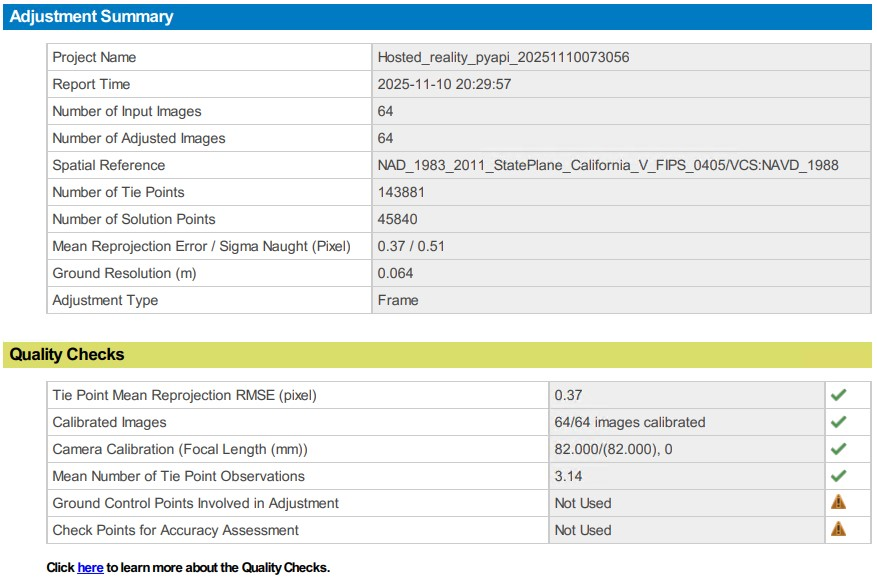

## Step 4: Get Results

The final step after block adjustment is to generate products. The [reconstruct_surface()](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster._realitymapping_mission.Mission.reconstruct_surface) method can generate one or multiple reality mapping products- DSM, true ortho and DSM Mesh from adjusted imagery.

In [ ]:
mission_products_2d = mission.reconstruct_surface(
    scenario= "AerialNadir",
    quality= "Ultra",
    output_dsm_name= "DigitalAerial2D_p_dsm",
    output_true_ortho_name= "DigitalAerial2D_p_ortho",
    output_dsm_mesh_name= "DigitalAerial2D_p_mesh"
)

## Conclusion

You've successfully completed a reality mapping workflow for digital aerial imagery using the ArcGIS API for Python. In this tutorial, you:

- Created a reality mapping project and mission for nadir digital aerial imagery.
- Performed block adjustment to geometrically correct your imagery collection.
- Generated DSM, true ortho and DSM mesh products.

See additional guides to see the same concept and workflow demonstrated here adapted for different raster types:
  * [UAV](../guide/create-trueortho-dsm-from-drone-imagery)
  * [obligue digital aerial](../guide/create-3D-digital-aerial-products)
  * [satellite imagery](../guide/create-trueortho-dsm-from-satellite-imagery)